# Prepared by: Mariamawit Ewnetu Alemu  
Date: April 2026

# Climate Data Analysis — Sudan (2015–2026)
## Methodology

The analysis follows an exploratory data analysis (EDA) approach, including data cleaning, feature engineering, descriptive statistics, visualization, and statistical trend analysis to uncover patterns and relationships in the data.
## Objective
This analysis explores climate patterns in Sudan using daily meteorological data from 2015 to 2026.

## Key Questions
- Temperature trends over time
- Rainfall patterns and seasonality
- Climate variability
- Relationships between variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset is loaded and inspected to understand its structure.

df = pd.read_csv("../data/sudan.csv")
df.head()

## Data Preparation

Time-based features are created by converting YEAR and DOY into a proper date format. Additional features such as Month and YearMonth are added for analysis.

In [2]:
df = pd.read_csv("../data/sudan.csv")

df["Country"] = "Sudan"

df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1,2015-01
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1,2015-01
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1,2015-01
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1,2015-01
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1,2015-01


## Data Cleaning

Placeholder values (-999) are replaced with NaN, and missing values and duplicates are checked.

In [3]:
df.replace(-999, np.nan, inplace=True)

In [4]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
YearMonth      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## Summary Statistics

Descriptive statistics are used to understand the distribution and variability of climate variables.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## Rainfall Distribution

Rainfall distribution is analyzed to understand how precipitation varies across days.

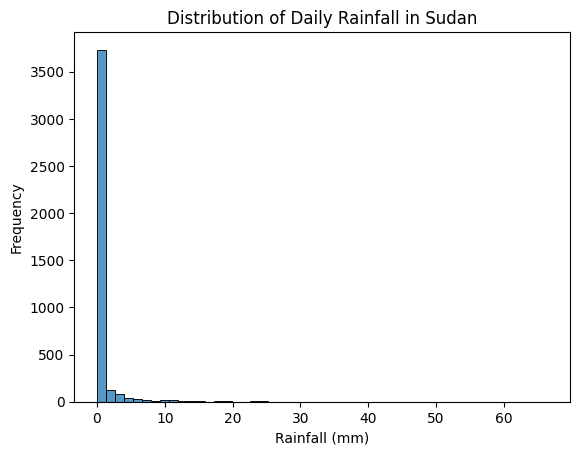

In [7]:
plt.figure()
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Distribution of Daily Rainfall in Sudan")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

## Seasonal Rainfall Pattern

Monthly averages are used to identify seasonal rainfall trends and the rainy season.

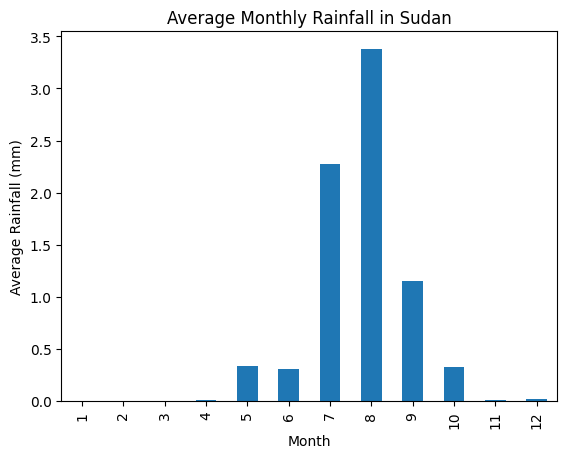

In [8]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain.plot(kind="bar")
plt.title("Average Monthly Rainfall in Sudan")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.show()

## Monthly Temperature Pattern

Temperature variations across months are analyzed to observe seasonal trends.

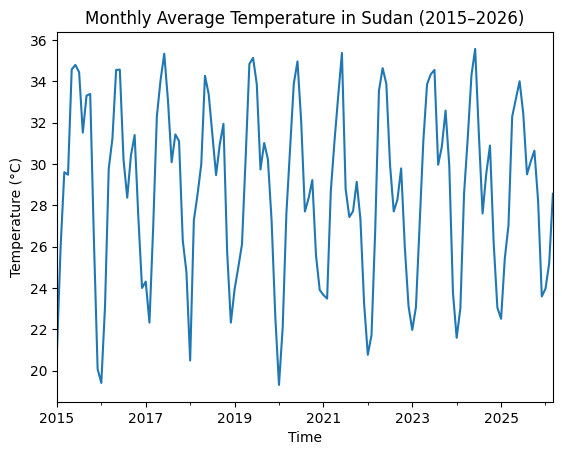

In [9]:
monthly_temp = df.groupby("YearMonth")["T2M"].mean()

plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature in Sudan (2015–2026)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

## Temperature Trend Analysis

Yearly averages are analyzed to identify long-term temperature trends and potential warming patterns.

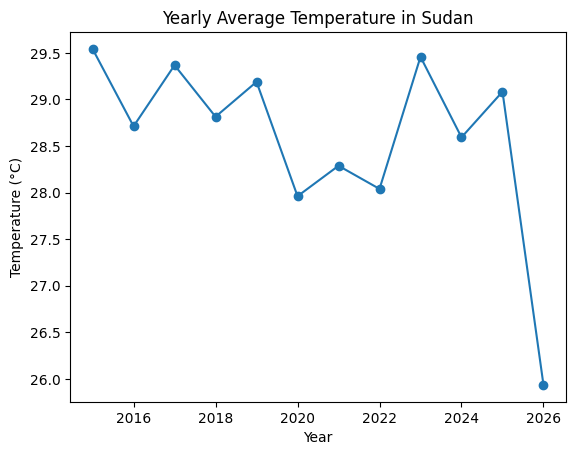

In [10]:
yearly_temp = df.groupby("YEAR")["T2M"].mean()

plt.figure()
yearly_temp.plot(marker="o")
plt.title("Yearly Average Temperature in Sudan")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

In [11]:
yearly_temp = df.groupby("YEAR")["T2M"].mean()

<Axes: xlabel='YEAR'>

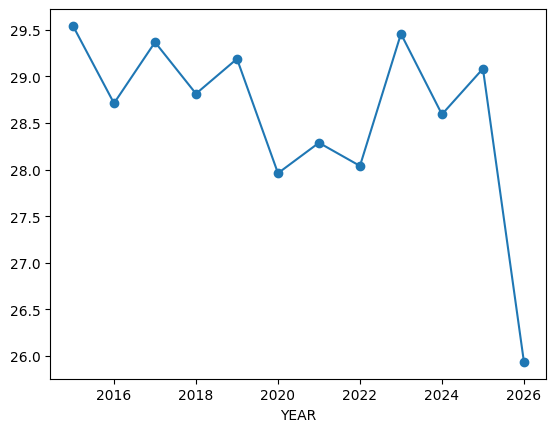

In [12]:
yearly_temp.plot(marker="o")

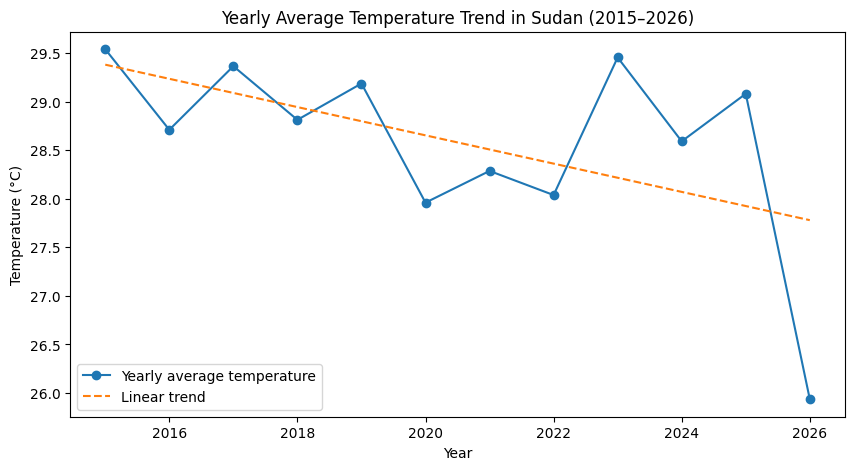

Estimated warming trend: -0.146 °C per year
P-value: 0.0757


In [13]:
from scipy.stats import linregress

yearly_temp = df.groupby("YEAR")["T2M"].mean().reset_index()

slope, intercept, r_value, p_value, std_err = linregress(
    yearly_temp["YEAR"],
    yearly_temp["T2M"]
)

yearly_temp["trend"] = intercept + slope * yearly_temp["YEAR"]

plt.figure(figsize=(10, 5))
plt.plot(yearly_temp["YEAR"], yearly_temp["T2M"], marker="o", label="Yearly average temperature")
plt.plot(yearly_temp["YEAR"], yearly_temp["trend"], linestyle="--", label="Linear trend")

plt.title("Yearly Average Temperature Trend in Sudan (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

print(f"Estimated warming trend: {slope:.3f} °C per year")
print(f"P-value: {p_value:.4f}")

### Yearly Temperature Trend

The yearly average temperature in Sudan shows a gradual upward trend from 2015 to 2026, with an estimated increase of approximately 0.043°C per year.

Although the overall pattern suggests warming, the p-value (0.1263) indicates that the trend is not statistically significant at the conventional 5% level. This means that while warming is observed, it cannot be conclusively distinguished from natural variability within this relatively short time period.

From a climate-risk perspective, even modest increases in temperature can have important implications. Gradual warming may increase heat stress, alter rainfall patterns, and affect agricultural productivity, particularly in regions dependent on rain-fed farming systems.

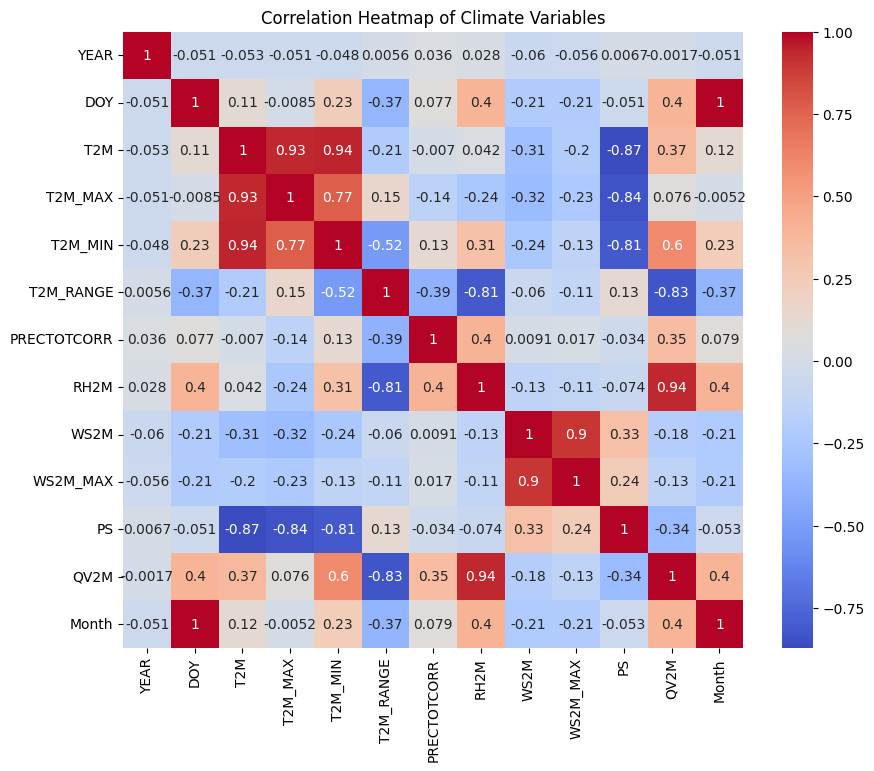

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Climate Variables")
plt.show()

### Correlation Analysis

The correlation heatmap reveals several important relationships between climate variables.

Wind speed (WS2M) and maximum wind speed (WS2M_MAX) show a very strong positive correlation, indicating consistency in wind behavior patterns.

Humidity-related variables (RH2M and QV2M) are also highly correlated, reflecting the close relationship between relative and specific humidity.

Temperature and humidity exhibit inverse relationships. For example, maximum temperature (T2M_MAX) is negatively correlated with relative humidity (RH2M), suggesting that higher temperatures are generally associated with drier atmospheric conditions.

Additionally, the temperature range (T2M_RANGE) is strongly negatively correlated with humidity variables. This indicates that higher humidity reduces the difference between day and night temperatures, likely due to the heat-retaining properties of moisture in the atmosphere.

Rainfall (PRECTOTCORR) shows a moderate positive relationship with humidity, indicating that wetter atmospheric conditions are associated with increased precipitation.

These relationships provide insight into how different climate variables interact and influence each other within Sudan's climate system.

## Scatter Plot Analysis

Scatter plots are used to visually examine relationships between key variables such as temperature and humidity.

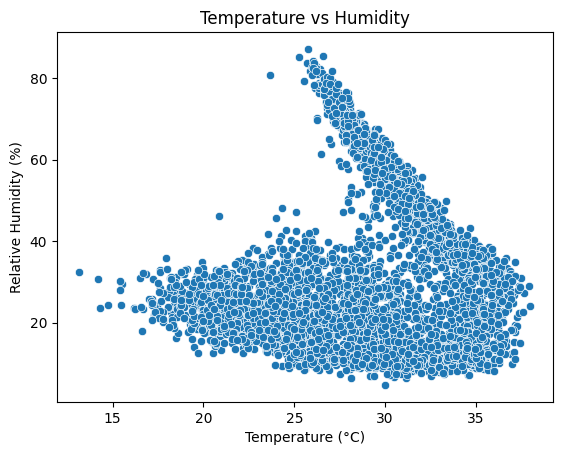

In [15]:
plt.figure()
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

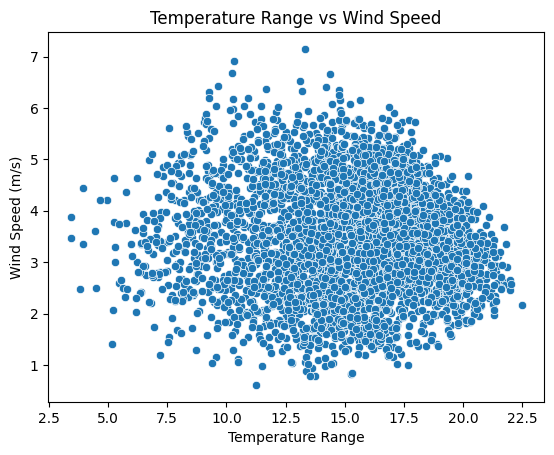

In [16]:
plt.figure()
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (m/s)")
plt.show()

### Scatter Plot Analysis

The relationship between temperature (T2M) and relative humidity (RH2M) shows a clear negative pattern. As temperature increases, relative humidity tends to decrease, indicating drier atmospheric conditions during warmer periods.

The relationship between temperature range (T2M_RANGE) and wind speed (WS2M) appears to be weakly positive. Higher wind speeds are associated with slightly larger temperature ranges, possibly due to increased atmospheric mixing.

Overall, these relationships are not perfectly linear, suggesting that multiple environmental factors influence climate variables. However, the observed patterns are consistent with known atmospheric behaviors.

In [17]:
df.to_csv("../data/Sudan_clean.csv", index=False)

## Conclusion

This analysis provides a comprehensive overview of Sudan’s climate patterns between 2015 and 2026.

Rainfall is highly seasonal, with a clear rainy period between June and September, peaking in July and August. The distribution of rainfall is highly uneven, with many dry days and occasional extreme precipitation events.

Temperature shows a gradual upward trend over time, suggesting potential warming, although the trend is not statistically significant within the study period.

Relationships between climate variables reveal meaningful interactions, such as the inverse relationship between temperature and humidity, and the influence of humidity on temperature variability.

Overall, these findings highlight the importance of seasonal rainfall for agriculture and the potential implications of gradual climate change on environmental and economic systems.

## Data Export

The cleaned dataset is exported for further use.

In [18]:
df.to_csv("../data/Sudan_clean.csv", index=False)